# 05 — Churn Prediction

Trains Logistic Regression and Random Forest churn classifiers on a
leakage-safe feature table generated by `src/feature_engineering.py`.

The models are evaluated and every customer's churn probability and
revenue-at-risk score are generated.

**Leakage safety:** cancellation_date and cancellation_reason are excluded,
and behavioral features use records available by the customer's observation
cutoff.


In [1]:

result = run_script(
    "feature_engineering.py"
)

if result.returncode != 0:
    print(
        "Feature engineering failed."
    )


Feature table built: (52000, 22)
Churn rate in feature table: 0.2064
Saved to C:\Users\ayuu1\Desktop\customer-retention-intelligence\customer-retention-intelligence\data\processed\feature_table.csv
Series([], dtype: int64)



In [2]:

result = run_script(
    "churn_model.py"
)

if result.returncode != 0:
    print(
        "Churn model failed."
    )


Loading feature table...
Feature table: (52000, 22), churn rate: 0.2064

=== Logistic Regression ===
              precision    recall  f1-score   support

    Retained       0.90      0.63      0.74     10317
     Churned       0.34      0.72      0.46      2683

    accuracy                           0.65     13000
   macro avg       0.62      0.68      0.60     13000
weighted avg       0.78      0.65      0.68     13000

Confusion matrix:
 [[6510 3807]
 [ 742 1941]]

=== Random Forest ===
              precision    recall  f1-score   support

    Retained       0.95      0.91      0.93     10317
     Churned       0.71      0.82      0.76      2683

    accuracy                           0.89     13000
   macro avg       0.83      0.87      0.85     13000
weighted avg       0.90      0.89      0.90     13000

Confusion matrix:
 [[9411  906]
 [ 470 2213]]

Model comparison:
               model  accuracy  precision  recall  f1_score  roc_auc
Logistic Regression    0.6501     0.3377  

## Inspect saved model outputs

In [3]:

import pandas as pd

comparison = pd.read_csv(
    ROOT
    / "outputs"
    / "model_results"
    / "model_comparison.csv"
)

print(
    comparison.to_string(index=False)
)


              model  accuracy  precision  recall  f1_score  roc_auc
Logistic Regression    0.6501     0.3377  0.7234    0.4604   0.7407
      Random Forest    0.8942     0.7095  0.8248    0.7628   0.9447


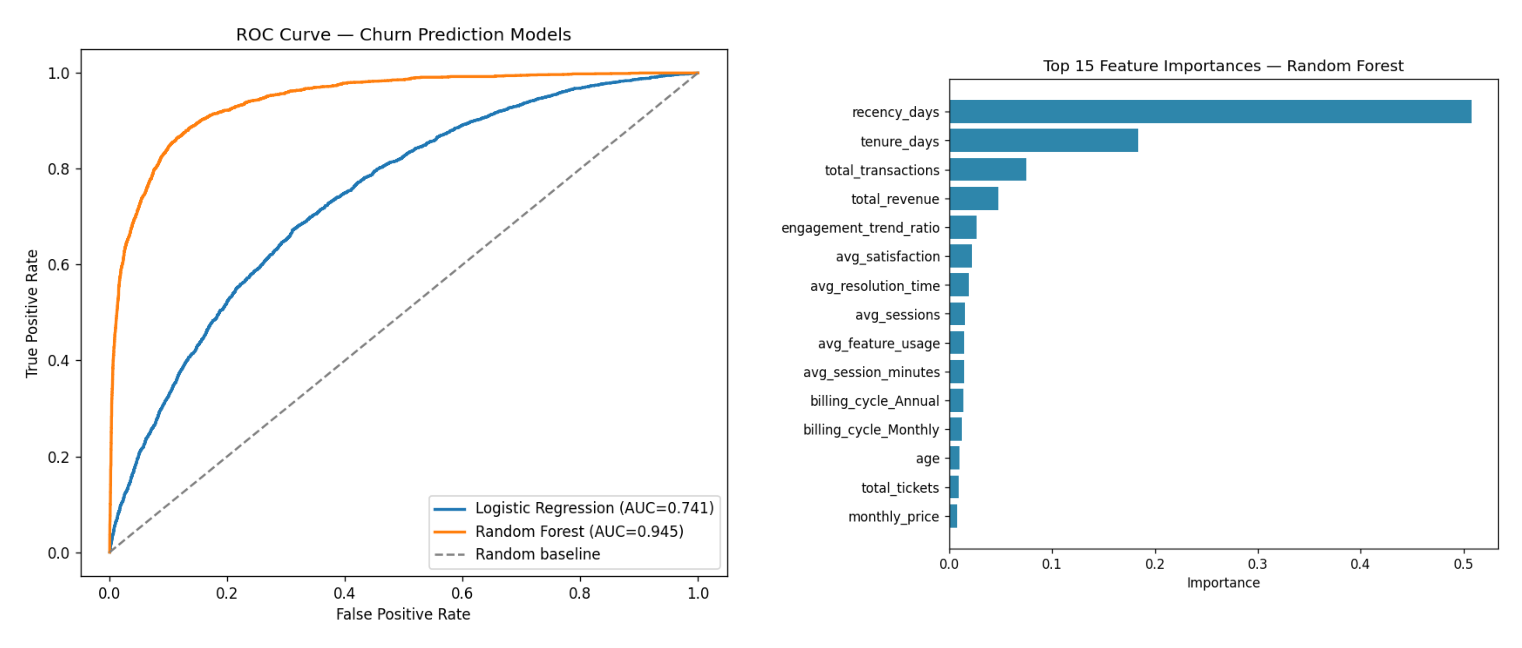

In [4]:

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

roc_path = (
    ROOT
    / "outputs"
    / "figures"
    / "roc_curve.png"
)

importance_path = (
    ROOT
    / "outputs"
    / "figures"
    / "feature_importance.png"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

axes[0].imshow(
    mpimg.imread(roc_path)
)

axes[0].axis("off")

axes[1].imshow(
    mpimg.imread(importance_path)
)

axes[1].axis("off")

plt.tight_layout()

plt.show()


**Model choice:** Random Forest was selected based on higher ROC-AUC.
Because the business goal is to catch as many at-risk customers as possible,
recall on the churned class is particularly important.

## Revenue at risk & retention priority

In [5]:

priority = pd.read_csv(
    ROOT
    / "outputs"
    / "tables"
    / "retention_priority.csv"
)

print(
    priority[
        "retention_priority"
    ].value_counts()
)

print()

total_risk = (
    priority["annualized_revenue"]
    * priority["churn_probability"]
).sum()

print(
    "Total annualized revenue at risk "
    f"(Active customers, prob-weighted): "
    f"${total_risk:,.2f}"
)

print()

print(
    "Top 10 retention-priority customers:"
)

print(
    priority
    .sort_values(
        "churn_probability",
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)


retention_priority
Priority 4 - Low Risk                        38119
Priority 3 - Medium Risk / High Value         1693
Priority 1 - High Risk / High Value           1117
Priority 2 - High Risk / Medium-Low Value      337
Name: count, dtype: int64

Total annualized revenue at risk (Active customers, prob-weighted): $1,255,230.48

Top 10 retention-priority customers:
 customer_id plan_name  annualized_revenue  churn_probability risk_level                        retention_priority
       42057  Standard              191.88             0.9622       High       Priority 1 - High Risk / High Value
       45365  Standard              172.68             0.9589       High       Priority 1 - High Risk / High Value
       19449  Standard              191.88             0.9563       High       Priority 1 - High Risk / High Value
       32202  Standard              191.88             0.9553       High       Priority 1 - High Risk / High Value
        8023  Standard              153.48             